# P4 — Transfer Learning & Fine-Tuning (CPU-Friendly)
## Data Set: Oxford-IIIT Pet 
- #### Feature Extraction vs Fine-Tuning | Performance Comparison
### Models: VGG16 • ResNet50 • DenseNet121
#### Solution Notebook

**Hardware assumption:** CPU-only laptops/PC are acceptable (training time may vary).  
**Dataset:** Oxford-IIIT Pet (37 classes)  
**Recommended settings:** `IMG_SIZE=(128,128)`, `BATCH_SIZE=32`, `EPOCHS=5-6` (CPU-friendly)

---

This solution notebook provides a clean reference implementation for:
- Building a reproducible `tf.data` pipeline
- Training **frozen-backbone** models (feature extraction)
- Running **one controlled fine-tuning** experiment
- Comparing results (accuracy, training time, parameter counts)


## Q0 — Setup (Ungraded)
#### Import libraries, set seeds, and verify TensorFlow / TFDS.

In [4]:
import os, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers
from tensorflow.keras.applications import resnet, vgg16, densenet
import sys
import numpy as np
import time
import tensorflow as tf
print(sys.version)
print("TensorFlow:", tf.__version__)
import importlib.metadata
print(importlib.metadata.version("tensorflow-datasets"))
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
import tensorflow_datasets as tfds
print(tfds)

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
TensorFlow: 2.21.0
4.9.10
<module 'tensorflow_datasets' from 'C:\\Users\\jevin\\miniconda3\\envs\\spyder-310\\lib\\site-packages\\tensorflow_datasets\\__init__.py'>


## ✅ Student Instructions (Start Here)

Your work begins in the **next code cells (Q1–Q9)** and continues by answering questions in the **Markdown cells (Q10–Q13)**. These correspond to the questions listed in the assignment description on Canvas. Complete each cell by following the instructions provided in the **preceding Markdown cells**.

Tasks:
- This assignment focuses on **transfer learning** with pretrained CNN backbones.
- You will train **three frozen-backbone models** for a fair comparison:
  - **VGG16** (frozen base)
  - **ResNet50** (frozen base)
  - **DenseNet121** (frozen base)
- Then run **one controlled fine-tuning experiment** (unfreeze a small portion of one backbone with a smaller learning rate).
- Keep your training CPU-feasible (use the recommended settings unless you have a GPU).

## Q1 — Load Dataset & Inspect
Use TFDS: `oxford_iiit_pet` and inspect shapes/classes.
### Student Tasks

- Load the Oxford-IIIT Pet dataset and split into ds_train (80%), ds_val (20%), and ds_test.

- Extract number of classes and class names from ds_info.

- Display one sample: image shape, label index, and class name.

In [3]:

#============================================================
#Question Q1 — Load Oxford-IIIT Pet Dataset (Fill in the Blanks)
#============================================================
#Complete the TODO sections to:
#1) Load the Oxford-IIIT Pet dataset using TensorFlow Datasets
#2) Create train/validation/test splits
#3) Extract class names and number of classes
#4) Print dataset information
#5) Inspect one example image and label
#============================================================

# TODO 1: Load dataset with train/validation/test splits


(ds_train, ds_val, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]", "test"],
    as_supervised=True,
    with_info=True,
)

# TODO 2: Get number of classes
num_classes = ds_info.features["label"].num_classes

# TODO 3: Get class names
class_names = ds_info.features["label"].names

# TODO 4: Print dataset information
print("Num classes:", num_classes)
print("Example classes:", class_names[:37])

# TODO 5: Inspect one example from the training set
for x, y in ds_train.take(1):
    print("Raw image shape:", x.shape, 
          "| label:", int(y), 
          "| class:", class_names[int(y)])



Num classes: 37
Example classes: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
Raw image shape: (500, 500, 3) | label: 33 | class: Sphynx
C:\Users\jevin\tensorflow_datasets


## Q2 — Preprocessing & `tf.data` Pipeline
Resize to **128×128**, normalize, add light augmentation for training.

### Student Tasks

- Set image size and batch size.

- Preprocess images by resizing and normalizing.

- Apply data augmentation to the training dataset.

- Create batched and prefetched train, validation, and test pipelines.

In [49]:
#============================================================
#Question Q2 — Image Preprocessing & Data Pipeline (Fill in the Blanks)
#============================================================
#Complete the TODO sections to:
#1) Define image size (128×128) and batch size (32 to 64)
#2) Implement preprocessing (resize + normalization)
#3) Implement simple data augmentation
#4) Build TensorFlow data pipelines
#5) Shuffle, batch, and prefetch the datasets
#============================================================

# TODO 1: Define image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# ------------------------------------------------------------
# TODO 2: Preprocessing function
# Resize images and normalize pixel values to [0,1]
# ------------------------------------------------------------
@tf.function
def preprocess(image, label):
    
    # Resize image
    image = tf.image.resize(image, IMG_SIZE)
    
    # Convert to float32
    image = tf.cast(image, tf.float32)
    
    # Normalize pixels
    image = image / 255
    
    return image, label

# ------------------------------------------------------------
# TODO 3: Data augmentation function
# ------------------------------------------------------------
@tf.function
def augment(image, label):
    
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    
    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.2)
    
    return image, label

# ------------------------------------------------------------
# TODO 4: Apply preprocessing and augmentation
# ------------------------------------------------------------
train_ds = ds_train.map(preprocess, num_parallel_calls=AUTOTUNE)\
                   .map(augment, num_parallel_calls=AUTOTUNE)

val_ds   = ds_val.map(preprocess, num_parallel_calls=AUTOTUNE)

test_ds  = ds_test.map(preprocess, num_parallel_calls=AUTOTUNE)

# ------------------------------------------------------------
# TODO 5: Shuffle, batch, and prefetch
# ------------------------------------------------------------
train_ds = train_ds.shuffle(1000, seed=SEED)\
                   .batch(BATCH_SIZE)\
                   .prefetch(AUTOTUNE)

val_ds   = val_ds.batch(BATCH_SIZE)\
                 .prefetch(AUTOTUNE)

test_ds  = test_ds.batch(BATCH_SIZE)\
                  .prefetch(AUTOTUNE)

print("Ready:", train_ds, val_ds, test_ds)



Ready: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


## Q3 — Utilities: Compile / Train / Evaluate / Count Params

### Student Tasks

- Compile the model using the Adam optimizer, sparse categorical cross-entropy loss, and accuracy metric.

- Train the model for several epochs and measure the training time.

- Evaluate the trained model on the validation and test datasets and report accuracy.

In [50]:
# ============================================================
# Question Q3 — Model Training Utilities (Fill in the Blanks)
# ============================================================
# Complete the TODO sections to:
# 1) Compile a model using the Adam optimizer
# 2) Define the loss function for multi-class classification
# 3) Track accuracy during training
# 4) Compute total model parameters
# 5) Train the model and measure training time
# 6) Evaluate the model on validation and test datasets
# ============================================================

import numpy as np
import time
import tensorflow as tf

# ------------------------------------------------------------
# TODO 1: Compile the model
# ------------------------------------------------------------
def compile_model(model, lr=1e-3):

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )

    return model

# ------------------------------------------------------------
# TODO 2: Compute total parameters of the model
# ------------------------------------------------------------
def total_params(model):

    return int(np.sum([np.prod(v.shape) for v in model.trainable_weights])) + \
           int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))


# ------------------------------------------------------------
# TODO 3: Train the model and measure training time
# ------------------------------------------------------------
def train_and_time(model, run_name, epochs=8):

    t0 = time.time()

    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1
    )

    dt = time.time() - t0

    return hist, dt


# ------------------------------------------------------------
# TODO 4: Evaluate the model
# ------------------------------------------------------------
def evaluate(model, name):

    v = model.evaluate(val_ds, verbose=1)

    t = model.evaluate(train_ds, verbose=1)

    print(f"{name} | Val acc: {v[1]:.4f} | Test acc: {t[1]:.4f}")

    return {
        "val_loss": v[0],
        "val_acc": v[1],
        "test_loss": t[0],
        "test_acc": t[1],
    }

## Q4 — Backbones & Transfer Model Builder

We will compare three pretrained ImageNet backbones using the **same head design** (GAP + Dropout + Dense):
- **VGG16**
- **ResNet50**
- **DenseNet121**

For feature extraction, keep the backbone **frozen** (`train_base=False`). For fine-tuning, unfreeze a small number of top layers with a smaller learning rate.

### Student Tasks

- Implement a function to load a pretrained backbone model (VGG16, ResNet50, or DenseNet121).

- Build a transfer learning model by adding a Global Average Pooling and classification layer.

- Optionally unfreeze the last layers of the backbone to perform fine-tuning with a smaller learning rate.


In [5]:
# ============================================================
# Question Q4 — Transfer Learning Model Construction (Fill in the Blanks)
# ============================================================
# Complete the TODO sections to:
# 1) Build a backbone model using pretrained ImageNet weights
# 2) Support VGG16, ResNet50, and DenseNet121 architectures
# 3) Attach a classifier head using Global Average Pooling
# 4) Create a full transfer learning model
# 5) Implement fine-tuning by unfreezing part of the backbone
# ============================================================

# ------------------------------------------------------------
# TODO 1: Build backbone model
# ------------------------------------------------------------


def build_backbone(backbone_name: str):
    """Return (base_model, preprocess_fn) for a supported backbone."""

    name = backbone_name.lower()

    if name == "vgg16":
        base = tf.keras.applications.VGG16(
            weights="imagenet",
            include_top=False,
            input_shape=IMG_SIZE + (3,)
        )

        preprocess_fn = vgg16.preprocess_input

    elif name == "resnet50":
        base = tf.keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=IMG_SIZE + (3,)
        )

        preprocess_fn = resnet.preprocess_input

    elif name in ["densenet121", "dense121"]:
        base = tf.keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=IMG_SIZE + (3,)
        )

        preprocess_fn = densenet.preprocess_input

    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    return base, preprocess_fn


# ------------------------------------------------------------
# TODO 2: Build transfer learning model
# ------------------------------------------------------------
def build_transfer_model(backbone_name="resnet50", train_base=False, dropout=0.2):
    """Backbone + GAP head. Returns (model, base)."""

    base, preprocess_fn = build_backbone(backbone_name)

    # Freeze or unfreeze backbone
    base.trainable = bool(train_base)

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

    # Apply preprocessing function
    x = preprocess_fn(inputs * 255)

    # Forward pass through backbone
    x = base(x, training=False)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dropout regularization
    x = layers.Dropout(dropout)(x)

    # Output classification layer
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    # Build final model
    model = tf.keras.Model(
        inputs,
        outputs,
        name=f"{backbone_name}_gap_{'ft' if train_base else 'fz'}"
    )

    return model, base


# ------------------------------------------------------------
# TODO 3: Fine-tune the backbone
# ------------------------------------------------------------
def fine_tune(model, base, n_unfreeze=30, lr=1e-5):
    """Unfreeze last layers of backbone and recompile model."""

    # Enable backbone training
    base.trainable = True


    if n_unfreeze is not None:
        for layer in base.layers[:-int(n_unfreeze)]:
            layer.trainable = False

    # Recompile model with smaller learning rate
    model = compile_model(model, lr=1e-5)

    return model

## Q5 — Model A: **VGG16** Transfer Learning (Frozen Base)
Train only a small classification head first (feature extraction).

### Student Tasks

- Build a transfer learning model using a frozen VGG16 backbone with a Global Average Pooling head.

- Compile the model and display the model summary.

- Train the model and evaluate its validation and test accuracy.

In [52]:
# ============================================================
# Question Q5 — Train VGG16 Transfer Learning Model (Fill in the Blanks)
# ============================================================
# Complete the TODO sections to:
# 1) Build a transfer learning model using the VGG16 backbone
# 2) Freeze the backbone during initial training
# 3) Compile the model with the provided compile_model() function
# 4) Train the model and record training time
# 5) Evaluate the trained model on validation and test datasets
# ============================================================

# ------------------------------------------------------------
# TODO 1: Build the VGG16 transfer learning model
# ------------------------------------------------------------
vgg_model, vgg_base = build_transfer_model(
    backbone_name="vgg16",
    train_base=False,
    dropout=0.1
)

# ------------------------------------------------------------
# TODO 2: Compile the model
# ------------------------------------------------------------
vgg_model = compile_model(
    vgg_model,
    lr=0.001
)

# ------------------------------------------------------------
# TODO 3: Display model summary
# ------------------------------------------------------------
vgg_model.summary()


# ------------------------------------------------------------
# TODO 4: Train the model
# ------------------------------------------------------------
history_vgg_fz, time_vgg_fz = train_and_time(
    vgg_model,
    "vgg16_frozen",
    epochs=epochs
)

# ------------------------------------------------------------
# TODO 5: Evaluate the trained model
# ------------------------------------------------------------
res_vgg_fz = evaluate(
    vgg_model,
    "vgg16_frozen"
)

Model: "vgg16_gap_fz"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 128, 128,  │          0 │ input_layer_21[0… │
│ (Multiply)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_27         │ (None, 128, 128)  │          0 │ multiply_10[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_28         │ (None, 128, 128)  │          0 │ multiply_10[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_29         │ (None, 128, 128)  │          0 │ multiply_10[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_9 (Stack)     │ (None, 128, 128,  │          0 │ get_item_27[0][0… │
│                     │ 3)                │            │ get_item_28[0][0… │
│                     │                   │            │ get_item_29[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 128, 128,  │          0 │ stack_9[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 4, 4, 512) │ 14,714,688 │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 512)       │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 37)        │     18,981 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,733,669 (56.20 MB)

 Trainable params: 18,981 (74.14 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 87s 939ms/step - accuracy: 0.1569 - loss: 16.0505 - val_accuracy: 0.3777 - val_loss: 6.4868
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 89s 962ms/step - accuracy: 0.4521 - loss: 6.0296 - val_accuracy: 0.5557 - val_loss: 4.1763
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 887ms/step - accuracy: 0.5839 - loss: 3.9079 - val_accuracy: 0.6155 - val_loss: 3.5601
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 81s 881ms/step - accuracy: 0.6692 - loss: 2.6822 - val_accuracy: 0.6535 - val_loss: 3.0977
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 894ms/step - accuracy: 0.7116 - loss: 2.0004 - val_accuracy: 0.6780 - val_loss: 2.9277
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 715ms/step - accuracy: 0.6780 - loss: 2.9277
92/92 ━━━━━━━━━━━━━━━━━━━━ 69s 746ms/step - accuracy: 0.8315 - loss: 0.9261
vgg16_frozen | Val acc: 0.6780 | Test acc: 0.8315


## Q6 — Model B: **ResNet50** Transfer Learning (Frozen Base)
Same head design as VGG16 model for a fair backbone comparison.

### Student Tasks

- Build a transfer learning model using a frozen ResNet50 backbone with a Global Average Pooling head.

- Compile the model and display the model summary.

- Train the model and evaluate its validation and test accuracy.

In [7]:

# ============================================================
# Question Q6 — Train ResNet50 Transfer Learning Model (Fill in the Blanks)
# ============================================================
# Complete the TODO sections to:
# 1) Build a transfer learning model using the ResNet50 backbone
# 2) Freeze the backbone during initial training
# 3) Compile the model using compile_model()
# 4) Train the model and record training time
# 5) Evaluate the trained model on validation and test datasets
# ============================================================

# ------------------------------------------------------------
# TODO 1: Build the ResNet50 transfer learning model
# ------------------------------------------------------------
resnet_model, resnet_base = build_transfer_model(
    backbone_name="resnet50",
    train_base=False,
    dropout=0.1
)

# ------------------------------------------------------------
# TODO 2: Compile the model
# ------------------------------------------------------------
resnet_model = compile_model(
    resnet_model,
    lr=0.001
)

# ------------------------------------------------------------
# TODO 3: Display model summary
# ------------------------------------------------------------
resnet_model.summary()


# ------------------------------------------------------------
# TODO 4: Train the model
# ------------------------------------------------------------
history_resnet_fz, time_resnet_fz = train_and_time(
    resnet_model,
    "resnet50_frozen",
    epochs=3
)

# ------------------------------------------------------------
# TODO 5: Evaluate the trained model
# ------------------------------------------------------------
res_resnet_fz = evaluate(
    resnet_model,
    "resnet50_frozen"
)


Model: "resnet50_gap_fz"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 37)        │     75,813 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,663,525 (90.27 MB)

 Trainable params: 75,813 (296.14 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 465ms/step - accuracy: 0.4997 - loss: 2.1507 - val_accuracy: 0.7351 - val_loss: 0.9496
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 434ms/step - accuracy: 0.7880 - loss: 0.6836 - val_accuracy: 0.7337 - val_loss: 0.9806
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 439ms/step - accuracy: 0.8539 - loss: 0.4313 - val_accuracy: 0.7677 - val_loss: 0.8301
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 512ms/step - accuracy: 0.9046 - loss: 0.2766 - val_accuracy: 0.7812 - val_loss: 0.8049
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 447ms/step - accuracy: 0.9307 - loss: 0.2154 - val_accuracy: 0.7840 - val_loss: 0.8268
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 346ms/step - accuracy: 0.7840 - loss: 0.8268
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 356ms/step - accuracy: 0.9704 - loss: 0.1043
resnet50_frozen | Val acc: 0.7840 | Test acc: 0.9704


## Q7 — Model C: **DenseNet121** Transfer Learning (Frozen Base)
Train a DenseNet121 backbone with the same GAP head design for a fair comparison against VGG16 and ResNet50.

### Student Tasks

- Build a transfer learning model using a frozen DenseNet121 backbone.

- Compile the model and display the model summary.

- Train the model and evaluate its validation and test accuracy.


In [8]:
# ============================================================
# Question Q7 — Train DenseNet121 Transfer Learning Model (Fill in the Blanks)
# ============================================================
# Complete the TODO sections to:
# 1) Build a transfer learning model using the DenseNet121 backbone
# 2) Freeze the backbone during initial training
# 3) Compile the model using compile_model()
# 4) Train the model and measure training time
# 5) Evaluate the trained model on validation and test datasets
# ============================================================

# ------------------------------------------------------------
# TODO 1: Build the DenseNet121 transfer learning model
# ------------------------------------------------------------
densenet_model, densenet_base = build_transfer_model(
    backbone_name="densenet121",    # e.g., densenet121
    train_base=False,
    dropout=0.1
)

# ------------------------------------------------------------
# TODO 2: Compile the model
# ------------------------------------------------------------
densenet_model = compile_model(
    densenet_model,
    lr=0.001
)

# ------------------------------------------------------------
# TODO 3: Display model summary
# ------------------------------------------------------------
densenet_model.summary()


# ------------------------------------------------------------
# TODO 4: Train the model
# ------------------------------------------------------------
history_densenet_fz, time_densenet_fz = train_and_time(
    densenet_model,
    "densenet121_frozen",
    epochs=3
)

# ------------------------------------------------------------
# TODO 5: Evaluate the trained model
# ------------------------------------------------------------
res_densenet_fz = evaluate(
    densenet_model,
    "densenet121_frozen"
)



Model: "densenet121_gap_fz"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_1 (Multiply)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │        37,925 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,075,429 (26.99 MB)

 Trainable params: 37,925 (148.14 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 61s 528ms/step - accuracy: 0.4032 - loss: 2.4228 - val_accuracy: 0.6848 - val_loss: 0.9850
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 47s 502ms/step - accuracy: 0.7395 - loss: 0.8320 - val_accuracy: 0.7880 - val_loss: 0.7076
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 45s 482ms/step - accuracy: 0.8193 - loss: 0.5661 - val_accuracy: 0.7812 - val_loss: 0.6686
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 492ms/step - accuracy: 0.8590 - loss: 0.4228 - val_accuracy: 0.8030 - val_loss: 0.6496
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 46s 497ms/step - accuracy: 0.8889 - loss: 0.3404 - val_accuracy: 0.8302 - val_loss: 0.5569
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 388ms/step - accuracy: 0.8302 - loss: 0.5569
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 395ms/step - accuracy: 0.9494 - loss: 0.2000
densenet121_frozen | Val acc: 0.8302 | Test acc: 0.9494


## Q8 — Fine-Tuning Experiment (One Controlled Change)

Fine-tune **all three backbone models (VGG16, ResNet50, and DenseNet121)** by unfreezing only the **top N layers**.

Report whether performance **improves, stays similar, or degrades**, and briefly explain why.

**Recommended**
- Start by unfreezing the **last 10–30 layers**
- Use a **smaller learning rate** (e.g., `1e-5`)
- Use **2-3 epochs**

### Student Tasks

- Fine-tune the **VGG16, ResNet50, and DenseNet121** models by unfreezing the top layers of each backbone.

- Train each fine-tuned model for several epochs.

- Evaluate the validation and test accuracy of each fine-tuned model.

## Q8(a) — Fine-tune VGG16

In [53]:

# ============================================================
# Question Q8(a) — Fine-Tune VGG16 Transfer Learning Model (Fill in the Blanks)
# ============================================================
# Complete the TODO sections to:
# 1) Fine-tune the VGG16 backbone by unfreezing the last layers
# 2) Re-compile the model with a smaller learning rate
# 3) Train the fine-tuned model
# 4) Evaluate the model after fine-tuning
# ============================================================

# ------------------------------------------------------------
# TODO 1: Fine-tune the VGG16 backbone
# ------------------------------------------------------------
vgg_model = fine_tune(
    vgg_model,
    vgg_base,
    n_unfreeze=30,
    lr=0.00001
)

# ------------------------------------------------------------
# TODO 2: Train the fine-tuned model
# ------------------------------------------------------------
history_vgg_ft, time_vgg_ft = train_and_time(
    vgg_model,
    "vgg16_finetuned",
    epochs=3
)

# ------------------------------------------------------------
# TODO 3: Evaluate the fine-tuned model
# ------------------------------------------------------------
res_vgg_ft = evaluate(
    vgg_model,
    "vgg16_finetuned"
)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 284s 3s/step - accuracy: 0.7198 - loss: 1.2108 - val_accuracy: 0.6671 - val_loss: 1.4009
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.8047 - loss: 0.6668 - val_accuracy: 0.6807 - val_loss: 1.3094
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 278s 3s/step - accuracy: 0.8522 - loss: 0.4762 - val_accuracy: 0.6943 - val_loss: 1.2064
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 694ms/step - accuracy: 0.6943 - loss: 1.2064
92/92 ━━━━━━━━━━━━━━━━━━━━ 65s 702ms/step - accuracy: 0.9579 - loss: 0.1567
vgg16_finetuned | Val acc: 0.6943 | Test acc: 0.9579


## Q8(b) — Fine-tune ResNet50

In [54]:

# ============================================================
# Question Q8(b) — Fine-Tune ResNet50 Transfer Learning Model (Fill in the Blanks)
# ============================================================
# Complete the TODO sections to:
# 1) Fine-tune the ResNet50 backbone by unfreezing the last layers
# 2) Re-compile the model with a smaller learning rate
# 3) Train the fine-tuned model
# 4) Evaluate the model after fine-tuning
# ============================================================

# ------------------------------------------------------------
# TODO 1: Fine-tune the ResNet50 backbone
# ------------------------------------------------------------
resnet_model = fine_tune(
    resnet_model,
    resnet_base,
    n_unfreeze=30,
    lr=0.00001
)

# ------------------------------------------------------------
# TODO 2: Train the fine-tuned model
# ------------------------------------------------------------
history_resnet_ft, time_resnet_ft = train_and_time(
    resnet_model,
    "ResNet50_finetuned",
    epochs=3
)

# ------------------------------------------------------------
# TODO 3: Evaluate the fine-tuned model
# ------------------------------------------------------------
res_resnet_ft = evaluate(
    resnet_model,
    "ResNet50_finetuned"
)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 780ms/step - accuracy: 0.8794 - loss: 0.5416 - val_accuracy: 0.7772 - val_loss: 0.7448
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 729ms/step - accuracy: 0.9470 - loss: 0.3448 - val_accuracy: 0.7690 - val_loss: 0.7525
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 71s 768ms/step - accuracy: 0.9701 - loss: 0.2479 - val_accuracy: 0.7717 - val_loss: 0.7562
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 441ms/step - accuracy: 0.7717 - loss: 0.7562
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 415ms/step - accuracy: 0.9963 - loss: 0.0983
ResNet50_finetuned | Val acc: 0.7717 | Test acc: 0.9963


## Q8(c) — Fine-tune DenseNet121

In [55]:

# ============================================================
# Question Q8(c) — Fine-Tune DenseNet121 Transfer Learning Model (Fill in the Blanks)
# ============================================================
# Complete the TODO sections to:
# 1) Fine-tune the DenseNet121 backbone by unfreezing the last layers
# 2) Re-compile the model with a smaller learning rate
# 3) Train the fine-tuned model
# 4) Evaluate the model after fine-tuning
# ============================================================

# ------------------------------------------------------------
# TODO 1: Fine-tune the DenseNet121 backbone
# ------------------------------------------------------------
densenet_model = fine_tune(
    densenet_model,
    densenet_base,
    n_unfreeze=30,
    lr=0.00001
)

# ------------------------------------------------------------
# TODO 2: Train the fine-tuned model
# ------------------------------------------------------------
history_densenet_ft, time_densenet_ft = train_and_time(
    densenet_model,
    "DenseNet121_finetuned",
    epochs=3
)

# ------------------------------------------------------------
# TODO 3: Evaluate the fine-tuned model
# ------------------------------------------------------------
res_densenet_ft = evaluate(
    densenet_model,
    "DenseNet121_finetuned"
)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8699 - loss: 0.5758 - val_accuracy: 0.8139 - val_loss: 0.6173
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 86s 930ms/step - accuracy: 0.8852 - loss: 0.5283 - val_accuracy: 0.8166 - val_loss: 0.6508
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 92s 997ms/step - accuracy: 0.8961 - loss: 0.4968 - val_accuracy: 0.8207 - val_loss: 0.6576
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 697ms/step - accuracy: 0.8207 - loss: 0.6576
92/92 ━━━━━━━━━━━━━━━━━━━━ 71s 770ms/step - accuracy: 0.9538 - loss: 0.3371
DenseNet121_finetuned | Val acc: 0.8207 | Test acc: 0.9538


## Q9 — Performance Comparison Table

#### Create a compact table comparing **frozen-backbone** models:

- VGG16 (frozen)
- ResNet50 (frozen)
- DenseNet121 (frozen)

#### Also include **fine-tuned** results for all three backbone.

### Student Tasks

- Create a comparison table summarizing the results of all models.

- Include validation accuracy, test accuracy, and training time.

- Compare frozen and fine-tuned models and identify the best-performing model.


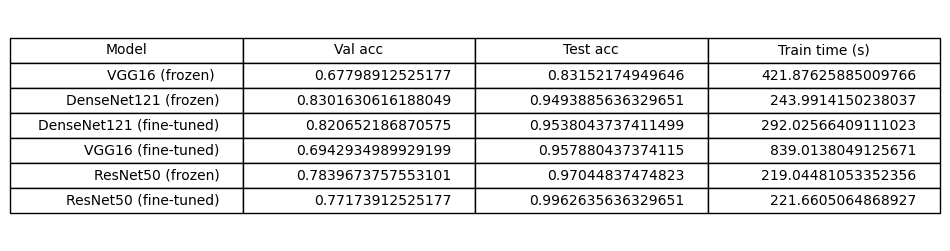

In [62]:

# ============================================================
# Question Q9 — Compare Model Results (Fill in the Blanks)
# ============================================================
# Complete the TODO sections to:
# 1) Store evaluation results for frozen models
# 2) Append results for fine-tuned models if they exist
# 3) Create a comparison table using pandas
# 4) Sort models by test accuracy
# ============================================================

# ------------------------------------------------------------
# TODO 1: Create result rows for frozen models
# ------------------------------------------------------------
rows = [

    {"Model": "VGG16 (frozen) ",       
     "Val acc": res_vgg_fz["val_acc"],       
     "Test acc": res_vgg_fz["test_acc"],       
     "Train time (s)": time_vgg_fz},

   {"Model": "ResNet50 (frozen)",    
     "Val acc": res_resnet_fz["val_acc"],    
     "Test acc": res_resnet_fz["test_acc"],    
     "Train time (s)": time_resnet_fz},

    {"Model": "DenseNet121 (frozen)", 
     "Val acc": res_densenet_fz["val_acc"],  
     "Test acc": res_densenet_fz["test_acc"],  
     "Train time (s)": time_densenet_fz},
]

# ------------------------------------------------------------
# TODO 2: Append results for fine-tuned models if available
# ------------------------------------------------------------

if "res_vgg_ft" in globals():
    rows.append({
        "Model": "VGG16 (fine-tuned)",
        "Val acc": res_vgg_ft["val_acc"],
        "Test acc": res_vgg_ft["test_acc"],
        "Train time (s)": time_vgg_ft
    })

if "res_resnet_ft" in globals():
    rows.append({
        "Model": "ResNet50 (fine-tuned)",
        "Val acc": res_resnet_ft["val_acc"],
        "Test acc": res_resnet_ft["test_acc"],
        "Train time (s)": time_resnet_ft
    })

if "res_densenet_ft" in globals():
    rows.append({
        "Model": "DenseNet121 (fine-tuned)",
        "Val acc": res_densenet_ft["val_acc"],
        "Test acc": res_densenet_ft["test_acc"],
        "Train time (s)": time_densenet_ft
    })


# ------------------------------------------------------------
# TODO 3: Create comparison dataframe
# ------------------------------------------------------------
df = pd.DataFrame(rows)


# ------------------------------------------------------------
# TODO 4: Sort models by test accuracy
# ------------------------------------------------------------
df = df.sort_values("Test acc", ascending=True)
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

tbl = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

plt.show()
#print(df)


## Short Written Questions

## **Q10** — What is the difference between *feature extraction* and *fine-tuning* in transfer learning?  
**Answer:** Feature extraction freezes the portion of the data that is pretrained and only trains new. A fine tuning unfreezes so those can be used to adapt to new features of data. 

## **Q11** — Why should the learning rate typically be lower during fine-tuning than during feature extraction?  

**Answer:** I made the mistake of not updating the epochs and learning rate. The learning rate was 0.001 and not the required 0.00001. What ended up happening was my fine tune data model accuracy and loss were much worse than the frozen model. I didn't catch the bug in the code until I ran it and seen single digit accuracy. Turns out this is because they are using pretrained weights and they are sensitive and a large learning rate would cause forgetting. I didn't know it at the time but making this mistake made me understand how important learning rates are in tranfer learning. 

## **Q12** — Give one reason why these backbones may behave differently on Oxford-IIIT Pet.  

**Answer:** Vgg, resnet and dense are better at course feature extraction and Oxford PEt items are more fine feature based. 

## **Q13** — Under what conditions can fine-tuning reduce performance compared to a frozen backbone?  

**Answer:** From the mistake I made I would say a learning rate of 1e-3 and epochs of 5 caused worse performance. I didn't catch the error until I was training the fine tuning. I expected the accuracy to be about the same or maybe better than the frozen but it was an order of magnitude worse. I didn't save it but I think it was around .05 accuracy. 

### 🎉 Congratulations!

You have successfully completed **P4-TL**. Excellent work exploring and comparing **RL**, specifically **VGG16**, **VGG16**, and **DenseNet121**. Analyzing how **TL, and fine-tuning** affect performance on the **Oxford-IIIT Pet** under **CPU-only training constraints**.

### **Submission Instructions**

Please submit a **GitHub repository link** on Canvas that contains:
- The **completed Jupyter notebook**
- Notebook runs **top-to-bottom** without errors

Before submitting, ensure that:
- All **code cells (Q1–Q9)** have been executed successfully
- All **Markdown responses (Q10–Q13)** have been completed
- The notebook is **saved after execution** so that outputs are visible

Once verified, **push the final version to GitHub** and submit the repository link on Canvas.